Found 241 CP files and 241 LSP files.
Loading Convective Precipitation (CP)...


C:\Users\tomy3\AppData\Local\Temp\ipykernel_28952\2387232559.py:21: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_cp = xr.open_mfdataset(
C:\Users\tomy3\AppData\Local\Temp\ipykernel_28952\2387232559.py:21: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_cp = xr.open_mfdataset(


Loading Large-Scale Precipitation (LSP)...


C:\Users\tomy3\AppData\Local\Temp\ipykernel_28952\2387232559.py:27: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_lsp = xr.open_mfdataset(
C:\Users\tomy3\AppData\Local\Temp\ipykernel_28952\2387232559.py:27: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_lsp = xr.open_mfdataset(


Computing Total Precipitation...
Flattening time dimensions...
Resampling to Daily...


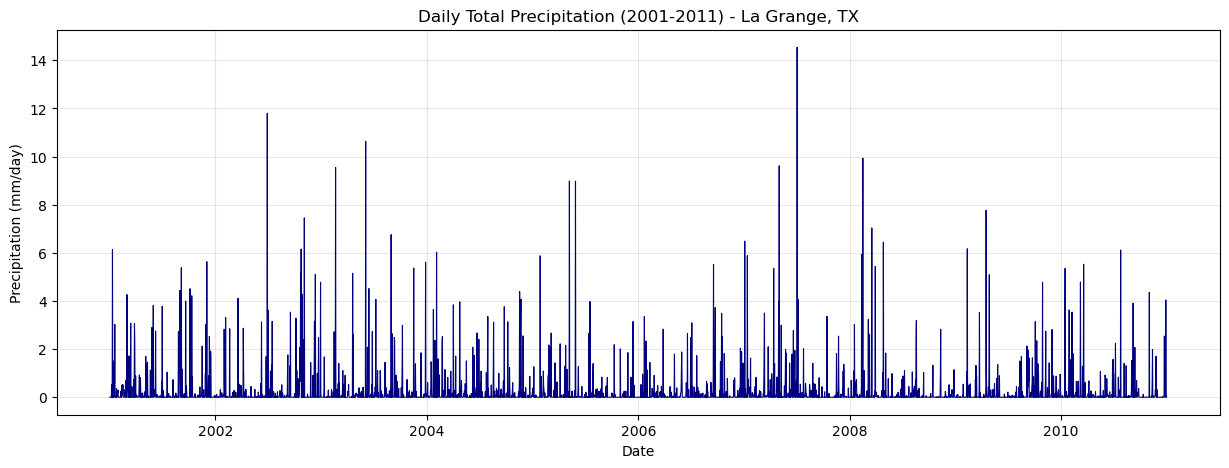

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import glob
import os
import pandas as pd
import numpy as np


all_files = sorted(glob.glob("ncardata/824200*.nc"))
cp_files = [f for f in all_files if '.CP.' in f and os.path.getsize(f) > 0]
lsp_files = [f for f in all_files if '.LSP.' in f and os.path.getsize(f) > 0]

print(f"Found {len(cp_files)} CP files and {len(lsp_files)} LSP files.")


def preprocess_spatial(ds):
    
    return ds.sel(latitude=29.91, longitude=263.12, method='nearest')

print("Loading Convective Precipitation (CP)...")
ds_cp = xr.open_mfdataset(
    cp_files, combine='nested', concat_dim='forecast_initial_time',
    preprocess=preprocess_spatial, join='override', coords='minimal'
)

print("Loading Large-Scale Precipitation (LSP)...")
ds_lsp = xr.open_mfdataset(
    lsp_files, combine='nested', concat_dim='forecast_initial_time',
    preprocess=preprocess_spatial, join='override', coords='minimal'
)


try:
    print("Computing Total Precipitation...")

    total_acc = ds_cp['CP'] + ds_lsp['LSP']

    
    first_hour = total_acc.isel(forecast_hour=0)
    subsequent_hours = total_acc.diff('forecast_hour', label='upper')
    
    hourly_rates = xr.concat([first_hour, subsequent_hours], dim='forecast_hour')

    print("Flattening time dimensions...")
   
    f_hour = hourly_rates.forecast_hour
    if not np.issubdtype(f_hour.dtype, np.timedelta64):
        f_hour_delta = pd.to_timedelta(f_hour.values.astype(float), unit='h')
        hourly_rates = hourly_rates.assign_coords(forecast_hour=f_hour_delta)

    
    valid_times = hourly_rates.forecast_initial_time + hourly_rates.forecast_hour
    hourly_rates = hourly_rates.assign_coords(valid_time=valid_times)

    
    hourly_flat = hourly_rates.stack(z=('forecast_initial_time', 'forecast_hour'))
    
   
    hourly_flat = hourly_flat.swap_dims({'z': 'valid_time'})
    hourly_series = hourly_flat.drop_vars(['z', 'forecast_initial_time', 'forecast_hour'])
    
   
    hourly_series = hourly_series.sortby('valid_time')


    print("Resampling to Daily...")
    
    daily_precip = (hourly_series * 1000).resample(valid_time='1D').sum()
    daily_precip = daily_precip.where(daily_precip >= 0, 0)

    # Final Plot
    plt.figure(figsize=(15, 5))
    daily_precip.plot(color='navy', linewidth=0.8)
    plt.title("Daily Total Precipitation (2001-2011) - La Grange, TX")
    plt.ylabel("Precipitation (mm/day)")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Save
    daily_precip.to_netcdf("HW02_LaGrange_Final.nc")
    

except Exception as e:
    print(f"An error occurred: {e}")